# 🎬 Netflix Content Library — Exploratory Data Analysis

**A Mini Project on Data Cleaning, Exploratory Data Analysis, Feature Engineering and Business Insight Generation**

---

### Objective
Explore the Netflix titles dataset to answer key business questions about content type, geographic
distribution, release trends, ratings, genres, duration and outliers — and translate the findings into
actionable recommendations for Netflix's content strategy team.

### Dataset
`NetFlix.csv` — 7,787 titles (Movies & TV Shows) available on Netflix, with 12 attributes:
`show_id, type, title, director, cast, country, date_added, release_year, rating, duration, genres, description`

### Tools Used
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`

### Structure
The notebook is organised into 13 tasks, each ending with a short **Interpretation** so every
chart/table is tied back to a business-relevant takeaway.



In [37]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings

warnings.filterwarnings('ignore')

# Consistent, Netflix-themed visual style used for every chart in this notebook
sns.set_theme(style='whitegrid')
NETFLIX_RED  = '#E50914'
NETFLIX_DARK = '#221f1f'
PALETTE      = ['#E50914', '#B81D24', '#221f1f', '#831010', '#564d4d', '#F5F5F1']
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


# Task 1: Dataset Understanding

In [40]:
df = pd.read_csv("NetFlix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [42]:
df.shape

(7787, 12)

In [44]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


## Observation
- Most columns are `object` dtype (text).
- `release_year` and `duration` are integers.
- `director`, `cast`, `country`, `date_added` and `rating` contain missing values.
- `duration` is a single numeric column but represents **two different units**: minutes for Movies and
  number of seasons for TV Shows. This matters — it must never be averaged or plotted across both types
  together (a mistake we deliberately avoid in Task 8 and Task 10).

In [49]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [51]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,TV-MA,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,334,3


## Purpose of `describe()`
- `describe()` (numeric) → count, mean, std, min/max, quartiles for numeric columns.
- `describe(include='object')` → count, number of unique values, most frequent value (`top`), and its
  frequency (`freq`) for text/categorical columns.

In [54]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

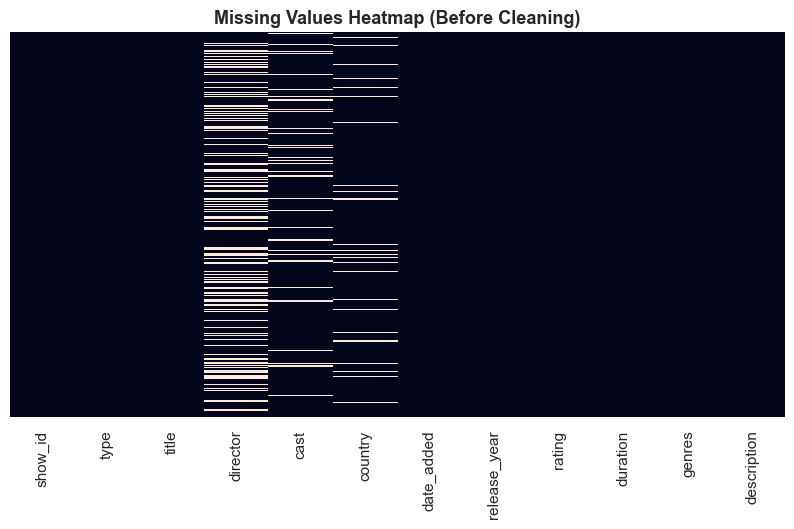

In [56]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='rocket'
)

plt.title("Missing Values Heatmap (Before Cleaning)")
plt.show()

### Missing values, visually.
Light/colored streaks mark null cells — `director`, `cast` and `country` stand out clearly.

In [59]:
df.duplicated().sum()

0

In [61]:
for col in df.columns:
    print(f"{col:15s}: {df[col].nunique()} unique values")

show_id        : 7787 unique values
type           : 2 unique values
title          : 7787 unique values
director       : 4049 unique values
cast           : 6831 unique values
country        : 681 unique values
date_added     : 1565 unique values
release_year   : 73 unique values
rating         : 14 unique values
duration       : 206 unique values
genres         : 492 unique values
description    : 7769 unique values


## Findings
- Dataset contains **7,787** Netflix titles.
- There are **12 features** describing content information.
- Missing values exist mainly in: **director**, **cast**, **country**, **date_added**, **rating**.
- Dataset contains both numerical and categorical variables.
- No duplicate rows.
- Data is suitable for: content-type analysis, country analysis, trend analysis, genre analysis,
  rating analysis, duration/outlier analysis and feature engineering.

# Task 2: Data Cleaning

In [65]:
# Always keep the original dataset untouched — all cleaning happens on a copy.
df_clean = df.copy()

In [67]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [69]:
# director: majority of rows have no director listed -> explicit 'Unknown' category
df_clean['director'] = df_clean['director'].fillna('Unknown')

# cast: no cast credited
df_clean['cast'] = df_clean['cast'].fillna('Not Available')

# country: production country not recorded
df_clean['country'] = df_clean['country'].fillna('Unknown')

# rating: very few missing values -> safe to impute with the mode
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])

# date_added: very few missing values -> safe to impute with the mode
df_clean['date_added'] = df_clean['date_added'].fillna(df_clean['date_added'].mode()[0])

In [71]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [73]:
df_clean.duplicated().sum()

0

### Converting the Date Column

In [76]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='mixed',
    dayfirst=True
)

df_clean['added_year']       = df_clean['date_added'].dt.year        # Year added to Netflix
df_clean['added_month']      = df_clean['date_added'].dt.month       # Month added (numeric)
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name()  # Month added (name)

### Data Quality Check — Timeline Consistency
A title should never be *added* to Netflix before it was *released*. This is a quick sanity check that
a raw, un-vetted CSV can hide inconsistencies of this kind.

In [79]:
timeline_issues = df_clean[df_clean['added_year'] < df_clean['release_year']]

print("Rows where 'added_year' is earlier than 'release_year':", len(timeline_issues))
timeline_issues[['title', 'release_year', 'added_year']].head()

Rows where 'added_year' is earlier than 'release_year': 12


,title,release_year,added_year
31,BoJack Horseman,2020,2019
1460,Fuller House,2020,2019
1783,Hans Teeuwen: Real Rancour,2018,2017
1937,Hilda,2021,2020
2203,Incoming,2019,2018


**Note:** a handful of rows show `added_year < release_year`. This happens because `release_year`
sometimes reflects a *re-release* or *festival premiere* year that pre-dates the title's Netflix listing
date recorded in the source metadata — not a data error requiring correction here, but worth flagging for
any downstream analysis that relies on strict chronological ordering.

### Understanding the `duration` Column
Recall from Task 1: `duration` mixes two units depending on `type`. We inspect this explicitly before
using the column anywhere.

In [83]:
df_clean[['type', 'duration']].head(10)

,type,duration
0,TV Show,4
1,Movie,143
2,Movie,124
3,Movie,90
4,TV Show,1
5,Movie,90
6,Movie,94
7,Movie,112
8,Movie,129
9,Movie,85


In [85]:
print("Duration range for Movies :", df_clean.loc[df_clean['type'] == 'Movie', 'duration'].min(),
      "-", df_clean.loc[df_clean['type'] == 'Movie', 'duration'].max(), "minutes")
print("Duration range for TV Shows :", df_clean.loc[df_clean['type'] == 'TV Show', 'duration'].min(),
      "-", df_clean.loc[df_clean['type'] == 'TV Show', 'duration'].max(), "seasons")

Duration range for Movies : 3 - 312 minutes
Duration range for TV Shows : 1 - 16 seasons


## Standardizing Text Columns

In [88]:
text_cols = ['title', 'director', 'cast', 'country', 'rating', 'genres']

for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

In [90]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           7787 non-null   object        
 1   type              7787 non-null   object        
 2   title             7787 non-null   object        
 3   director          7787 non-null   object        
 4   cast              7787 non-null   object        
 5   country           7787 non-null   object        
 6   date_added        7787 non-null   datetime64[ns]
 7   release_year      7787 non-null   int64         
 8   rating            7787 non-null   object        
 9   duration          7787 non-null   int64         
 10  genres            7787 non-null   object        
 11  description       7787 non-null   object        
 12  added_year        7787 non-null   int32         
 13  added_month       7787 non-null   int32         
 14  added_month_name  7787 n

# Task 3: Content Type Analysis

## 1. Count Content Types

In [94]:
df_clean['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

## 2. Number of Movies

In [97]:
movies_count = df_clean[df_clean['type'] == 'Movie'].shape[0]
print("Total Movies:", movies_count)

Total Movies: 5377


## 3. Number of TV Shows

In [100]:
tv_count = df_clean[df_clean['type'] == 'TV Show'].shape[0]
print("Total TV Shows:", tv_count)

Total TV Shows: 2410


## 4. Percentage Distribution

In [103]:
content_pct = round(df_clean['type'].value_counts(normalize=True) * 100, 2)
content_pct

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64

## 5. Count Plot

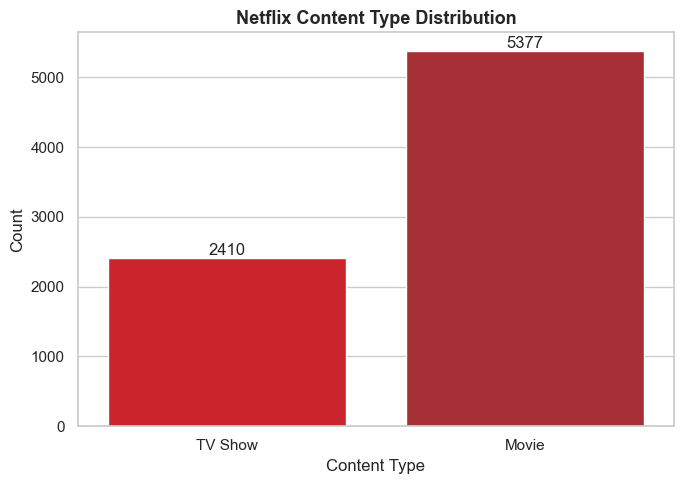

In [106]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x='type',
    hue='type',
    palette=PALETTE[:2],
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Pie Chart

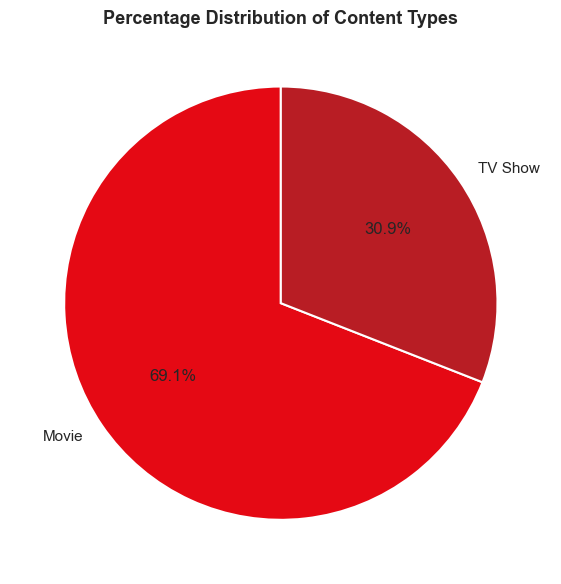

In [109]:
content_counts = df_clean['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE[:2],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title("Percentage Distribution of Content Types")
plt.tight_layout()
plt.show()

## Interpretation
- Netflix contains **5,377 Movies** and **2,410 TV Shows** (see `movies_count` / `tv_count` above).
- Movies account for roughly **69%** of the platform's content, TV Shows for **31%**.
- The platform has more than twice as many Movies as TV Shows — the content library is heavily
  movie-oriented, which has implications for licensing spend and content-acquisition strategy.

# Task 4: Country Analysis

## Questions
1. Top 10 content-producing countries.
2. Visualize country distribution.

In [114]:
df_clean['country'].head()

0            Brazil
1             India
2         Indonesia
3     United States
4    United Kingdom
Name: country, dtype: object

In [116]:
# A title can list several co-producing countries (comma-separated).
# For "who produces the most content" we take the FIRST listed country as the primary producer.
df_clean['primary_country'] = (
    df_clean['country']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [118]:
top_countries = df_clean['primary_country'].value_counts().head(10)
top_countries

primary_country
United States     2883
India              956
United Kingdom     577
Unknown            507
Canada             259
Japan              237
France             196
South Korea        194
Spain              168
Mexico             123
Name: count, dtype: int64

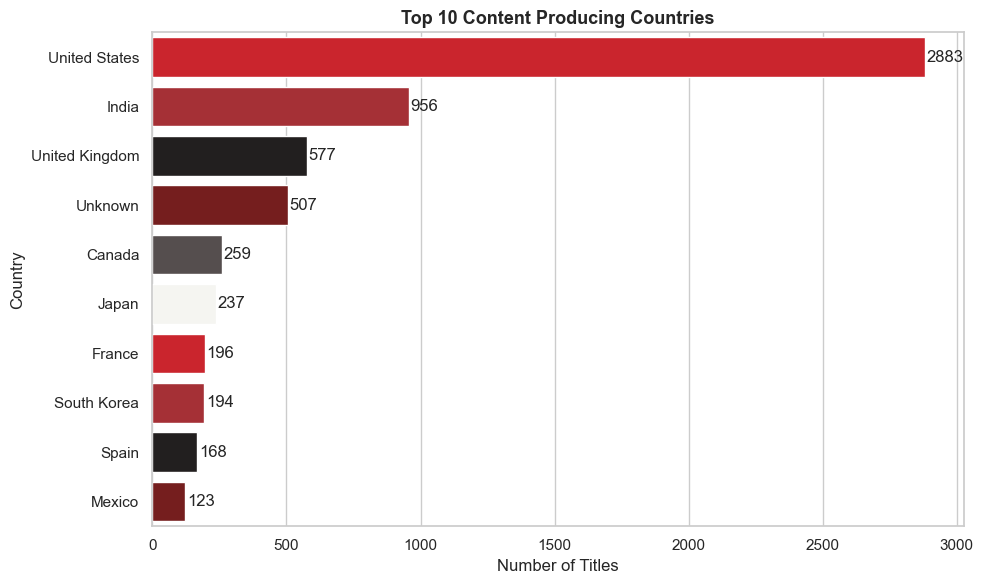

In [120]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette=PALETTE * 2,
    legend=False
)

for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

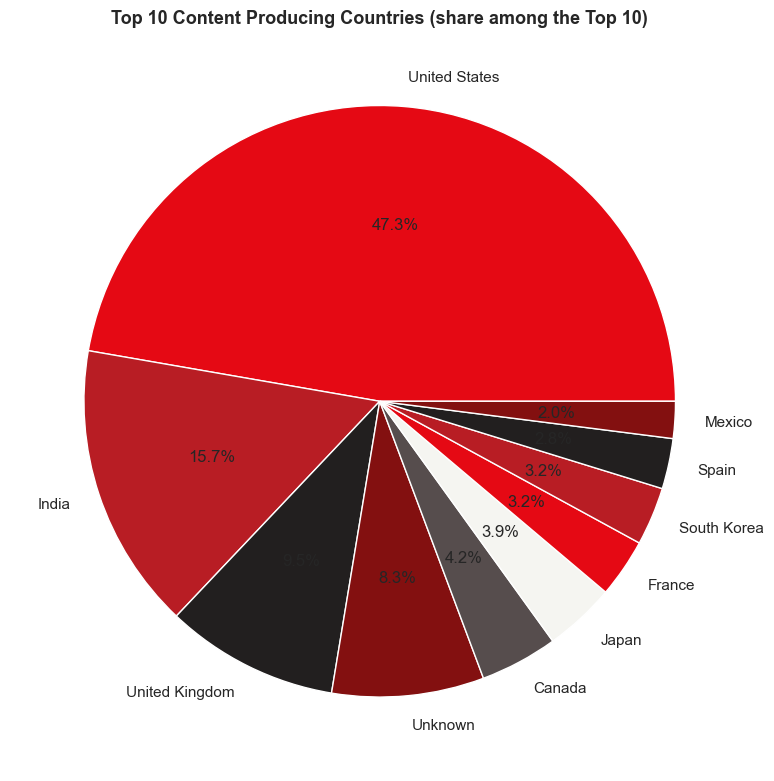

In [122]:
plt.figure(figsize=(8, 8))
plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct='%1.1f%%',
    colors=PALETTE * 2,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title("Top 10 Content Producing Countries (share among the Top 10)")
plt.tight_layout()
plt.show()

In [124]:
country_df = df_clean['primary_country'].value_counts().reset_index()
country_df.columns = ['Country', 'Count']
country_df.head(10)

,Country,Count
0,United States,2883
1,India,956
2,United Kingdom,577
3,Unknown,507
4,Canada,259
5,Japan,237
6,France,196
7,South Korea,194
8,Spain,168
9,Mexico,123


### Extra depth -- co-production countries
Looking only at the *primary* country hides collaborations. Exploding **all** listed countries per title
gives a fuller picture of where Netflix content is produced, including as a co-producer.

In [127]:
all_countries = (
    df_clean['country']
    .str.split(',')
    .explode()
    .str.strip()
)
all_countries = all_countries[all_countries != 'Unknown']

top_all_countries = all_countries.value_counts().head(10)
top_all_countries

country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

## Interpretation
### Key Findings
1. The United States dominates Netflix content production with **2,883** titles as primary producer.
2. India is the second-largest contributor with **956** titles.
3. The United Kingdom ranks third with **577** titles.
4. Asian countries such as India, Japan and South Korea contribute significantly to the platform.
5. More than 500 records have missing country information (shown as *Unknown*).
6. When co-production credits are counted (not just the primary country), the same top countries
   remain dominant, but several European countries move up -- showing Netflix's reliance on
   international co-production deals, not just single-country originals.
7. India's position as the second-largest content producer highlights the importance of the Indian
   entertainment market and Netflix's investment in regional content.

# Task 5: Yearly Trend Analysis

## Questions
1. Number of titles released each year.
2. Has content production increased over time?

In [132]:
yearly_titles = df_clean['release_year'].value_counts().sort_index()
yearly_titles.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    3
Name: count, dtype: int64

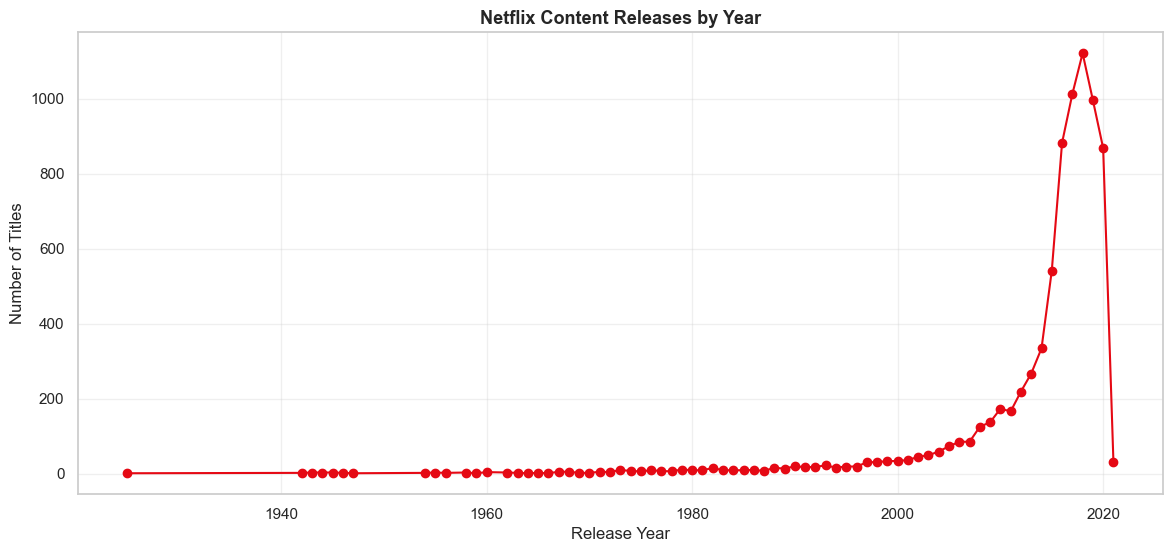

In [134]:
plt.figure(figsize=(14, 6))
plt.plot(yearly_titles.index, yearly_titles.values, marker='o', color=NETFLIX_RED)
plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
plt.show()

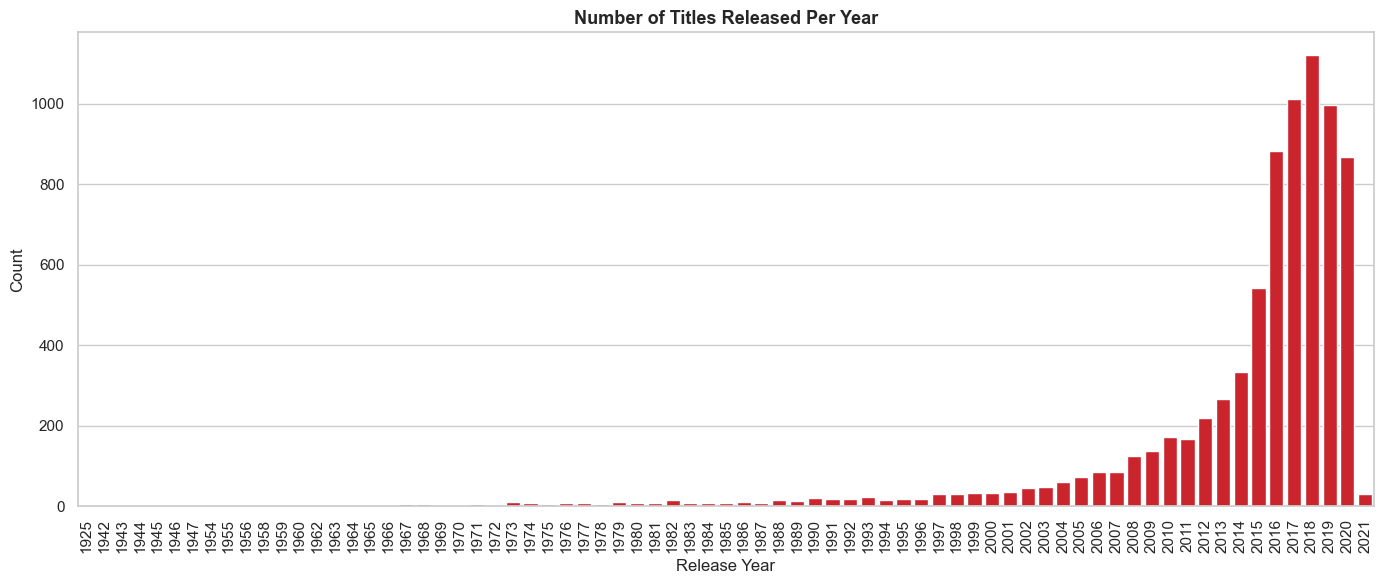

In [136]:
plt.figure(figsize=(14, 6))
sns.barplot(x=yearly_titles.index, y=yearly_titles.values, color=NETFLIX_RED)
plt.xticks(rotation=90)
plt.title("Number of Titles Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [138]:
peak_year = yearly_titles.idxmax()
peak_count = yearly_titles.max()
print("Peak Year:", peak_year)
print("Titles Released:", peak_count)

Peak Year: 2018
Titles Released: 1121


In [140]:
recent_trend = (
    df_clean[df_clean['release_year'] >= 2010]['release_year']
    .value_counts()
    .sort_index()
)
recent_trend

release_year
2010     173
2011     166
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

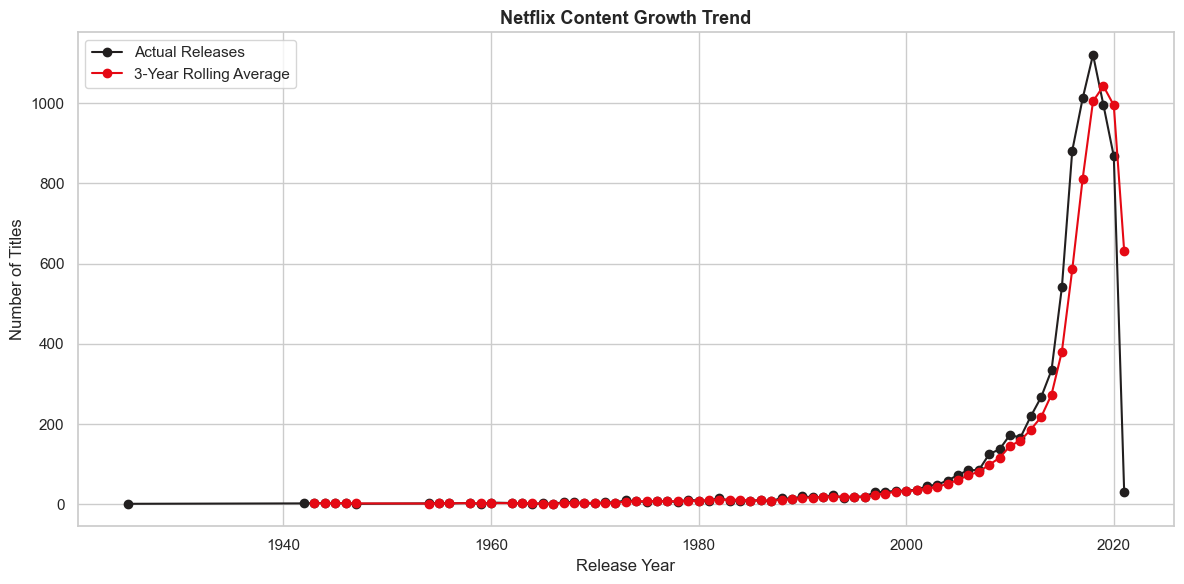

In [142]:
yearly_df = yearly_titles.reset_index()
yearly_df.columns = ['Year', 'Count']
yearly_df['Rolling_Avg'] = yearly_df['Count'].rolling(3).mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_df['Year'], yearly_df['Count'], marker='o', label='Actual Releases', color=NETFLIX_DARK)
plt.plot(yearly_df['Year'], yearly_df['Rolling_Avg'], marker='o', label='3-Year Rolling Average', color=NETFLIX_RED)
plt.title("Netflix Content Growth Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation
### Key Findings
1. Netflix content production increased steadily from 2007 to 2018.
2. The most significant growth occurred between 2015 and 2018.
3. Content production peaked in 2018 with **1,121** titles.
4. After 2018, the number of releases declined in the raw counts.
5. The very low count for 2021 reflects that the dataset was collected before that year was complete --
   not an actual production slowdown.

# Task 6: Rating Analysis

## Questions
1. Most common maturity rating.
2. Distribution of ratings.
3. Visualization using countplots.

In [147]:
rating_counts = df_clean['rating'].value_counts()
rating_counts

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [149]:
most_common_rating = df_clean['rating'].mode()[0]
print("Most Common Rating:", most_common_rating)

Most Common Rating: TV-MA


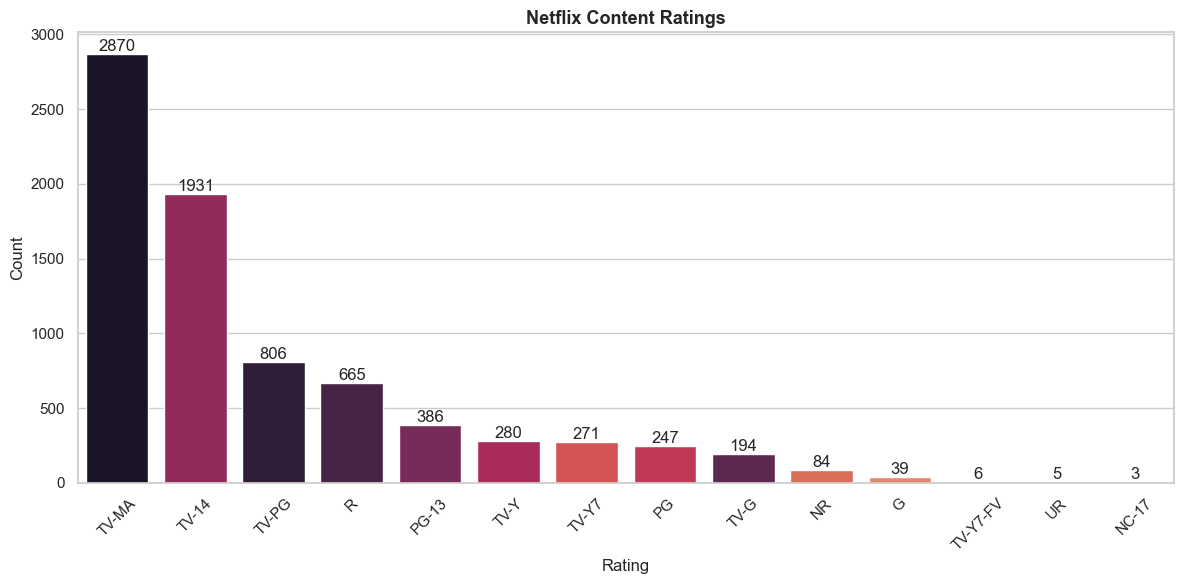

In [151]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_clean,
    x='rating',
    hue='rating',
    order=df_clean['rating'].value_counts().index,
    palette='rocket',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

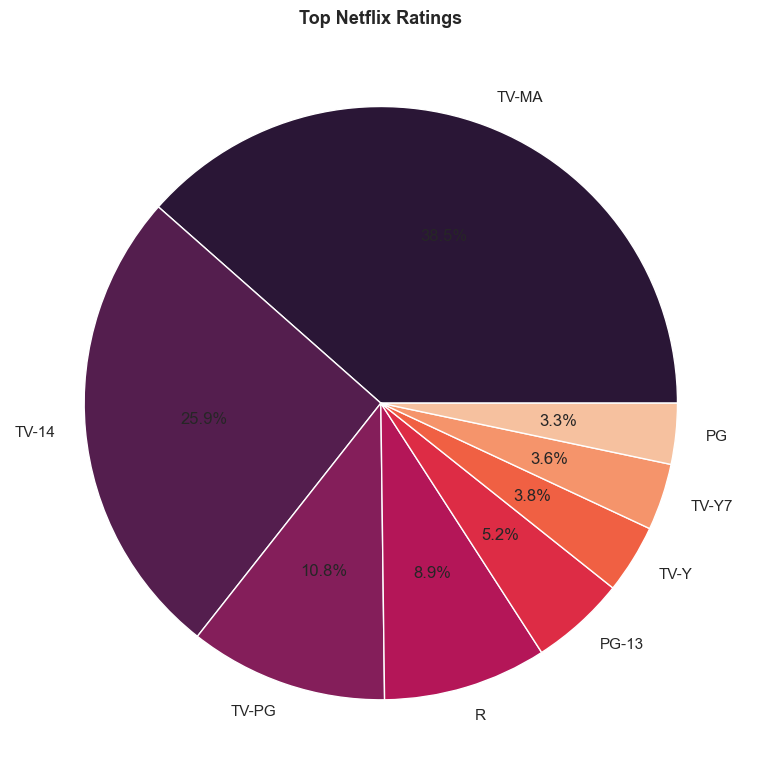

In [153]:
top_ratings = df_clean['rating'].value_counts().head(8)

plt.figure(figsize=(8, 8))
plt.pie(
    top_ratings.values,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('rocket', len(top_ratings)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title("Top Netflix Ratings")
plt.tight_layout()
plt.show()

## Interpretation
### Key Findings
1. **TV-MA** is the most common rating with **2,870** titles.
2. **TV-14** is the second most frequent rating with **1,931** titles.
3. Most Netflix content is intended for teenagers and adults.
4. Children's content (TV-Y, TV-Y7, TV-G) represents a much smaller portion of the catalog.
5. Mature content dominates the platform -- worth noting for family-plan positioning and parental-control
   messaging.

# Task 7: Genre Analysis

## Questions
1. Top 10 genres.
2. Most popular genre category.
3. Visualize findings.

In [158]:
df_clean['genres'].head(10)

0    International TV Shows, TV Dramas, TV Sci-Fi &...
1       Horror Movies, International Movies, Thrillers
2          Dramas, International Movies, Sports Movies
3                                             Comedies
4    British TV Shows, Docuseries, Science & Nature TV
5                        Independent Movies, Thrillers
6                         Action & Adventure, Comedies
7          Dramas, Independent Movies, Romantic Movies
8      Comedies, International Movies, Romantic Movies
9                                        Documentaries
Name: genres, dtype: object

In [164]:
genre_series = (
    df_clean['genres']
    .str.split(',')
    .explode()
    .str.strip()
)

In [166]:
genre_counts = genre_series.value_counts()
genre_counts.head(10)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

In [168]:
top10_genres = genre_counts.head(10)
print(top10_genres)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


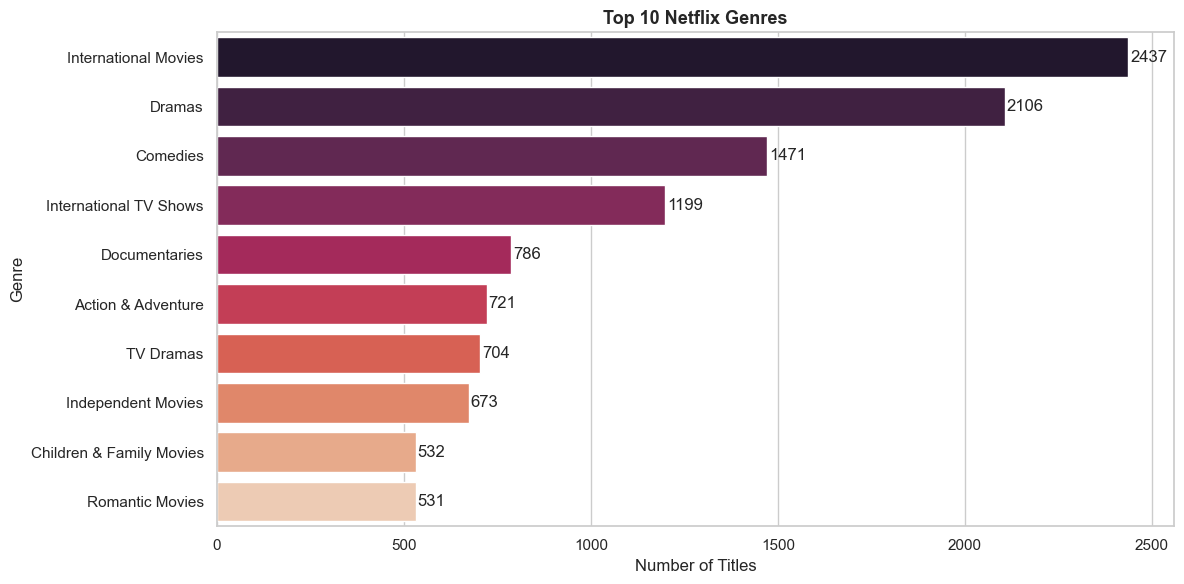

In [170]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top10_genres.values,
    y=top10_genres.index,
    hue=top10_genres.index,
    palette='rocket',
    legend=False
)

for i, value in enumerate(top10_genres.values):
    ax.text(value + 5, i, str(value), va='center')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

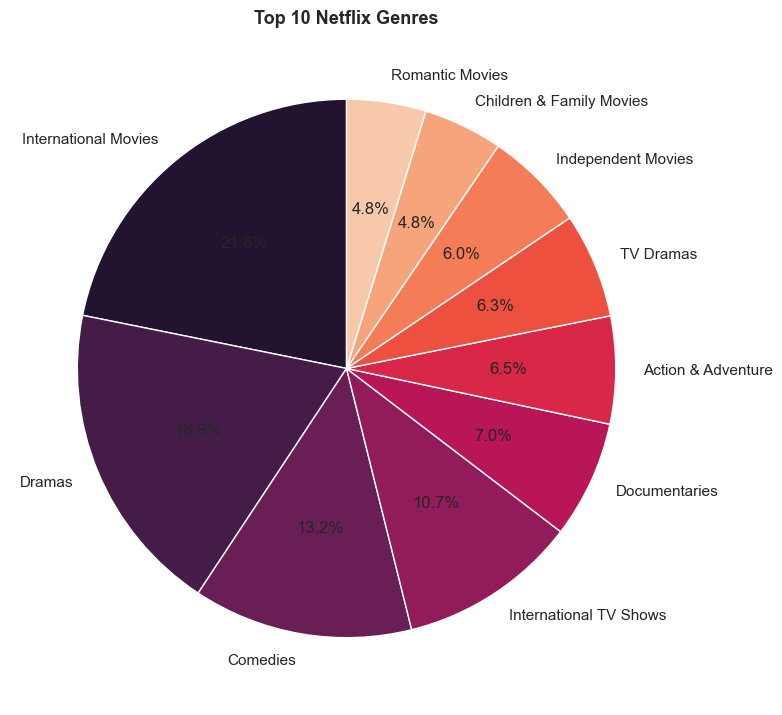

In [172]:
plt.figure(figsize=(8, 8))
plt.pie(
    top10_genres.values,
    labels=top10_genres.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('rocket', len(top10_genres))
)
plt.title("Top 10 Netflix Genres")
plt.tight_layout()
plt.show()

In [174]:
print("Most Popular Genre:", genre_counts.idxmax())
print("Number of Titles:", genre_counts.max())

Most Popular Genre: International Movies
Number of Titles: 2437


In [176]:
genre_percentage = round(genre_counts / genre_counts.sum() * 100, 2)
genre_percentage.head(10)

genres
International Movies        14.28
Dramas                      12.34
Comedies                     8.62
International TV Shows       7.02
Documentaries                4.60
Action & Adventure           4.22
TV Dramas                    4.12
Independent Movies           3.94
Children & Family Movies     3.12
Romantic Movies              3.11
Name: count, dtype: float64

## Interpretation
### Key Findings
1. **International Movies** is the most popular genre with **2,437** titles.
2. **Dramas** rank second with **2,106** titles.
3. **Comedies** are the third most common genre.
4. Netflix has a strong focus on international content, reflecting its strategy of serving a global
   audience rather than a single-market catalog.
5. Documentaries, Action & Adventure, and TV Dramas also make up a significant part of the library.

# Task 8: Duration Analysis

## Questions
1. Average movie duration.
2. Longest / shortest movie.
3. Distribution of movie duration.
4. *(Added)* Average number of seasons for TV Shows, and distribution.

**Important:** as established in Task 2, `duration` means minutes for Movies and seasons for TV Shows.
The two are analyzed **separately** below -- combining them would produce meaningless statistics.

In [181]:
movies   = df_clean[df_clean['type'] == 'Movie'].copy()
tv_shows = df_clean[df_clean['type'] == 'TV Show'].copy()

movies.rename(columns={'duration': 'duration_min'}, inplace=True)
tv_shows.rename(columns={'duration': 'seasons'}, inplace=True)

movies[['title', 'duration_min']].head()

,title,duration_min
1,1920,143
2,3 Heroines,124
3,Blue Mountain State: The Rise of Thadland,90
5,Blue Ruin,90
6,Blue Streak,94


### Movies -- Duration in Minutes

In [184]:
movies['duration_min'].describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

In [186]:
average_duration = movies['duration_min'].mean()
print("Average Movie Duration:", round(average_duration, 2), "minutes")

Average Movie Duration: 99.31 minutes


In [188]:
longest_movie = movies.loc[movies['duration_min'].idxmax()]
print(longest_movie[['title', 'duration_min']])

title           Black Mirror: Bandersnatch
duration_min                           312
Name: 7741, dtype: object


In [190]:
shortest_movie = movies.loc[movies['duration_min'].idxmin()]
print(shortest_movie[['title', 'duration_min']])

title           Silent
duration_min         3
Name: 5119, dtype: object


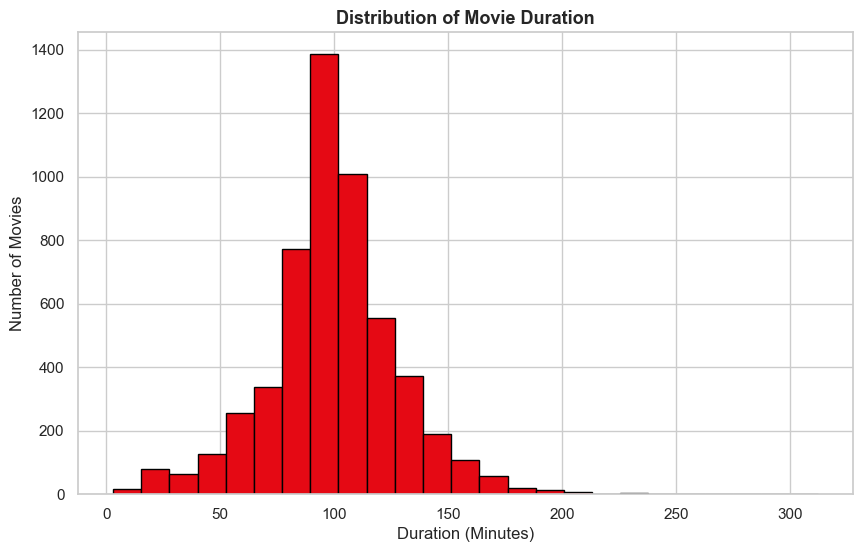

In [192]:
plt.figure(figsize=(10, 6))
plt.hist(movies['duration_min'], bins=25, edgecolor='black', color=NETFLIX_RED)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

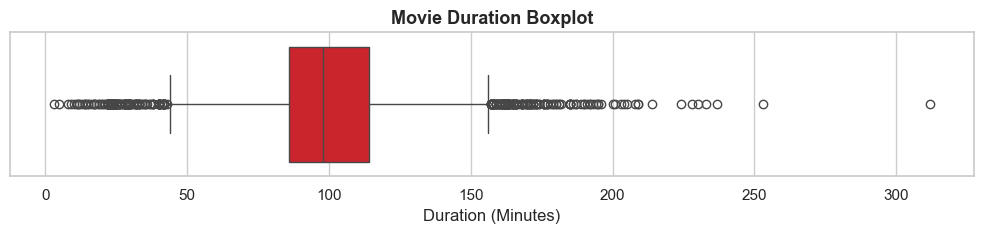

In [194]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=movies['duration_min'], color=NETFLIX_RED)
plt.title("Movie Duration Boxplot")
plt.xlabel("Duration (Minutes)")
plt.tight_layout()
plt.show()

### TV Shows -- Number of Seasons *(added analysis)*

In [197]:
tv_shows['seasons'].describe()

count    2410.000000
mean        1.775934
std         1.596359
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: seasons, dtype: float64

In [199]:
avg_seasons = tv_shows['seasons'].mean()
most_seasons_show = tv_shows.loc[tv_shows['seasons'].idxmax()]

print("Average number of seasons:", round(avg_seasons, 2))
print("TV Show with the most seasons:", most_seasons_show['title'], "-", most_seasons_show['seasons'], "seasons")

Average number of seasons: 1.78
TV Show with the most seasons: Grey's Anatomy - 16 seasons


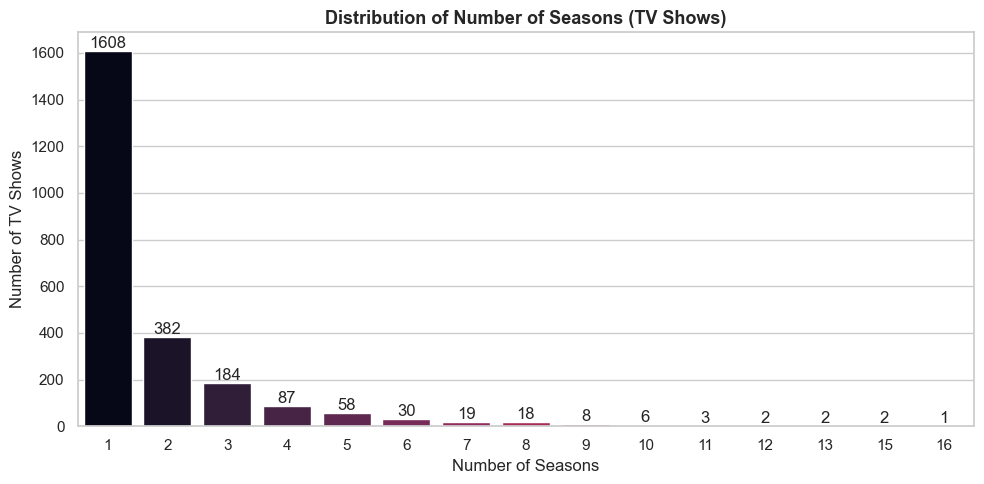

In [203]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=tv_shows,
    x='seasons',
    hue='seasons',
    palette='rocket',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of Number of Seasons (TV Shows)")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()

## Interpretation
- The average movie duration is **99.31 minutes**, close to the standard feature-film length.
- The shortest movie is **3 minutes** long; the longest is **312 minutes**.
- Most movies fall within a moderate duration range, with only a few exceptionally short or long titles.
- The overwhelming majority of Netflix TV Shows have **just 1 season**, meaning most series are
  short-lived or newly launched rather than long-running franchises -- a useful signal for renewal /
  cancellation strategy discussions.

# Task 9: Outlier Analysis

## Using movie duration
1. Detect outliers using IQR.
2. Detect outliers using Z-score.
3. Compare results.

In [208]:
Q1 = movies['duration_min'].quantile(0.25)
Q3 = movies['duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 44.0
Upper bound: 156.0


In [210]:
iqr_outliers = movies[
    (movies['duration_min'] < lower) |
    (movies['duration_min'] > upper)
]
print("Number of IQR Outliers:", len(iqr_outliers))

Number of IQR Outliers: 337


In [212]:
movies['z_score'] = zscore(movies['duration_min'])

In [214]:
z_outliers = movies[movies['z_score'].abs() > 3]
print("Number of Z-Score Outliers:", len(z_outliers))

Number of Z-Score Outliers: 45


In [216]:
print("IQR Outliers     :", len(iqr_outliers))
print("Z-Score Outliers :", len(z_outliers))

IQR Outliers     : 337
Z-Score Outliers : 45


## Interpretation
### Why the numbers differ
- **IQR** (337 outliers): flags any movie whose duration lies outside the normal interquartile range. It
  is more sensitive and catches many unusually short or long movies.
- **Z-Score** (45 outliers): only flags movies more than 3 standard deviations from the mean. It is
  stricter and identifies only the most extreme cases.

This difference is expected -- the two methods use different statistical criteria, and IQR is generally
preferred for skewed distributions (movie duration is right-skewed because of a handful of very long
titles), while Z-score assumes an approximately normal distribution.

# Task 10: Feature Engineering

### Create
- **Release Decade** -- 1980s / 1990s / 2000s / 2010s / 2020s
- **Content Age** -- Current Year - Release Year
- **Duration Category** (Movies only) -- Short / Medium / Long
- **Season Category** (TV Shows only, *added*) -- so the bug of applying minute-based bins to a
  season-count column (which would classify every TV Show as "Short") is avoided.

In [221]:
df_clean['Release Decade'] = pd.cut(
    df_clean['release_year'],
    bins=[1979, 1989, 1999, 2009, 2019, 2029],
    labels=['1980s', '1990s', '2000s', '2010s', '2020s']
)

df_clean['Release Decade'].value_counts().sort_index()

Release Decade
1980s     106
1990s     225
2000s     728
2010s    5711
2020s     899
Name: count, dtype: int64

In [223]:
current_year = 2026
df_clean['Content Age'] = current_year - df_clean['release_year']
df_clean[['release_year', 'Content Age']].head()

,release_year,Content Age
0,2020,6
1,2008,18
2,2016,10
3,2016,10
4,2017,9


**Fixing a subtle bug:** the `duration` column mixes minutes (Movies) and seasons (TV Shows).
Binning the *whole* column with minute-based thresholds (0-60-120-400) would silently mislabel every
TV Show as "Short" (since season counts are always small numbers). We therefore build the Duration
Category **from the Movies subset only**, and give TV Shows their own Season Category.

In [226]:
movies['Duration Category'] = pd.cut(
    movies['duration_min'],
    bins=[0, 60, 120, 400],
    labels=['Short', 'Medium', 'Long']
)

movies['Duration Category'].value_counts()

Duration Category
Medium    3920
Long      1011
Short      446
Name: count, dtype: int64

In [230]:
tv_shows['Season Category'] = pd.cut(
    tv_shows['seasons'],
    bins=[0, 1, 3, 100],
    labels=['Single Season', 'Few Seasons (2-3)', 'Long-Running (4+)']
)

tv_shows['Season Category'].value_counts()

Season Category
Single Season        1608
Few Seasons (2-3)     566
Long-Running (4+)     236
Name: count, dtype: int64

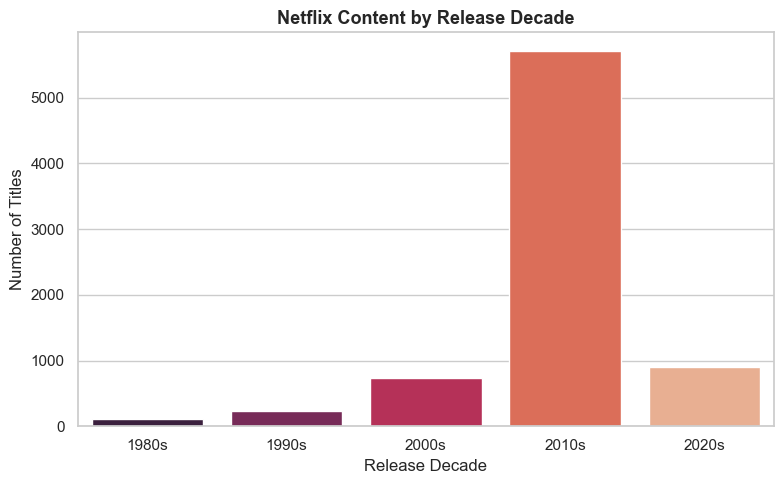

In [232]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='Release Decade',
    hue='Release Decade',
    order=['1980s', '1990s', '2000s', '2010s', '2020s'],
    palette='rocket',
    legend=False
)
plt.title("Netflix Content by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

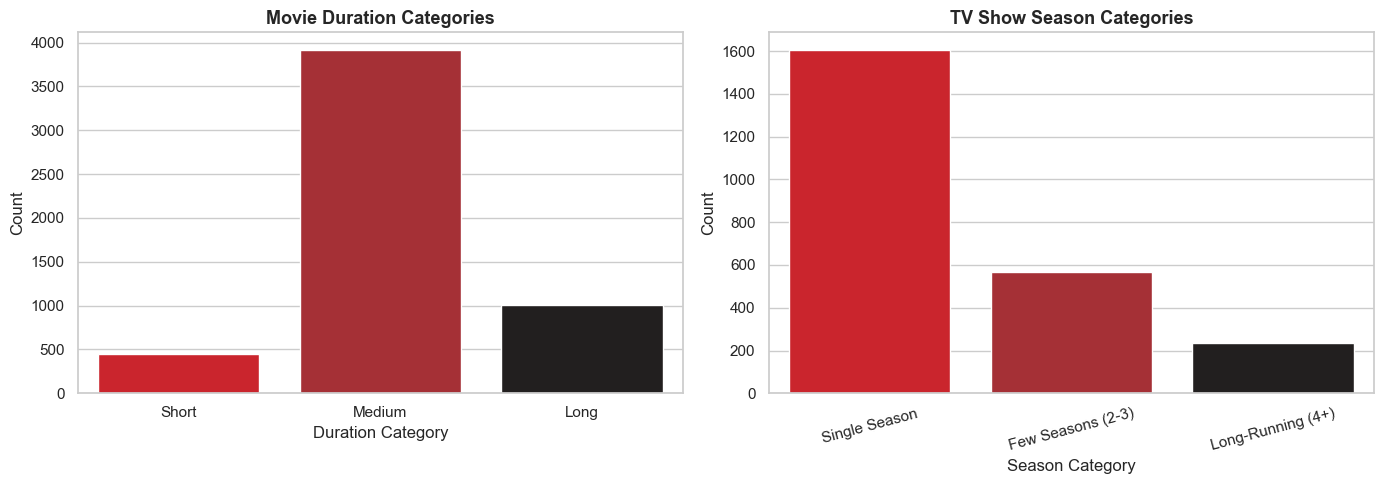

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=movies, x='Duration Category', hue='Duration Category',
    order=['Short', 'Medium', 'Long'], palette=PALETTE[:3], legend=False, ax=axes[0]
)
axes[0].set_title("Movie Duration Categories")
axes[0].set_xlabel("Duration Category")
axes[0].set_ylabel("Count")

sns.countplot(
    data=tv_shows, x='Season Category', hue='Season Category',
    order=['Single Season', 'Few Seasons (2-3)', 'Long-Running (4+)'],
    palette=PALETTE[:3], legend=False, ax=axes[1]
)
axes[1].set_title("TV Show Season Categories")
axes[1].set_xlabel("Season Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Interpretation
- **2010s** dominate the dataset with **5,711** titles -- Netflix's biggest content expansion happened
  during this decade.
- The **2020s** have fewer titles because the dataset only contains the early years of that decade.
- Medium-duration movies (60-120 min) are the largest category, roughly half of all movies -- standard
  feature-length films remain the platform's core offering.
- The large majority of TV Shows are **single-season** -- consistent with the seasons finding in Task 8,
  and a signal that most series never get renewed.

# Task 11: Multivariate Analysis

### Investigate
1. Content Type vs Rating
2. Content Type by Country
3. Movies released over time
4. Correlation among numeric features
5. *(Added)* Top directors and top actors by title count

### Use
Crosstab, Heatmaps, GroupBy